# 20 — W2 Phase 2: Fang-ViT frozen-embedding probe

Documents the [PLAN_CNN.md](../PLAN_CNN.md) §5.1 lead bet
(DECISIONS.md 2026-06-12, two entries):
[Fang et al. 2026](https://doi.org/10.1029/2025JH000827) released a ViT-B/16
pretrained (MAE+DINO, self-supervised) on **3.9M crops of the Murray Lab CTX
mosaic itself** ([Zenodo 18180801](https://doi.org/10.5281/zenodo.18180801)).
We extract **frozen GeM(p=3)-pooled embeddings** per tile (own-tile input +
3×3-context input, both bicubic→224) and append them as LightGBM feature
columns in the standard LOIO harness (`fa_gt_1e-2`, 38 v2 images).

**Result: both pre-declared reference gates pass at BOTH scales by the
largest margin of the program** — pooled PR-AUC 0.5651 → **0.7637** at S=64;
the S=32 Tier-1 collapse (0.4840) is **fixed** (0.7639). The 3×3-context
input is the carrier at both scales; GeM > mean > cls; the combined
64+192 cell is the best per-image variant.

**Caveats carried with the claim** (full text in DECISIONS.md):
1. *Transductive pretraining* — the FM saw test **pixels** (never labels)
   during SSL. Deployment estimand = Murray-mosaic inference, which is
   in-corpus everywhere, so LOIO is unbiased **for that estimand**; the
   optional empirical bound is a MOMO (disjoint-corpus) cross-check.
2. *Post-hoc assembly* — promotion requires the standing pre-declared
   confirmation on cohort-expansion images. No seed instability exists in
   this path (deterministic end to end).

Probe-tier code: `scripts/probes/_w2_fang_{embed,probe,patch_visual,azimuth}.py`.


In [1]:
import json
from pathlib import Path

import sys
REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO))
import src.modeling  # noqa: F401  -- Windows DLL bootstrap

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

FIG = REPO / "reports" / "figures"
PROBE = REPO / "models" / "fang_probe"
DOSSIER = pd.read_parquet(REPO / "dataset_v2/w1_dossier.parquet")
print("probe runs on disk:", sorted(p.name for p in PROBE.iterdir() if p.is_dir()))

probe runs on disk: ['emb_only', 'heads_knn50', 'heads_lgbm', 'heads_logreg', 't1_cls192', 't1_gem192', 't1_gem32', 't1_gem64', 't1_gem64_gem192', 't1_gem96', 't1_mean192']


## 1. Verdict tables — every probe variant vs its Tier-1 reference

**Variant naming.** Every variant is the same LightGBM binary classifier
(`fa_gt_1e-2`, standard LOIO) — only the **feature matrix** differs.
Building blocks: `t1` = the 52 handcrafted Tier-1 features
(intensity/GLCM/gradient/shadow); `gem{px}` = 768 frozen Fang-ViT embedding
columns, GeM(p=3)-pooled, computed from a {px}-px CTX input centered on the
tile (`cls`/`mean` = alternative poolings of the same tokens). At S=64
tiles the own-tile input is 64 px and the 3×3-context input is 192 px; at
S=32 tiles they are 32 px and 96 px.

| variant | feature matrix | n cols | tile scale |
|---|---|---|---|
| `t1_gem64` | Tier-1 + GeM embeddings of the tile itself (64 px) | 52+768 | S=64 |
| `t1_gem192` | Tier-1 + GeM embeddings of the 3×3 context (192 px) | 52+768 | S=64 |
| `t1_gem64_gem192` | Tier-1 + both embedding sets | 52+1536 | S=64 |
| `emb_only` | both embedding sets, **no** handcrafted features | 1536 | S=64 |
| `t1_cls192` / `t1_mean192` | pool ablation: CLS-token / mean-token instead of GeM | 52+768 | S=64 |
| `t1_gem32` | Tier-1 + GeM of the tile itself (32 px) | 52+768 | S=32 |
| `t1_gem96` | Tier-1 + GeM of the 3×3 context (96 px) | 52+768 | S=32 |

Gates (reference bars, not promotion): pooled ΔPR-AUC ≥ +0.03 vs Tier-1;
per-image ΔAUC median ≥ +0.05 with Wilcoxon p < 0.05 on dossier
validity-passing images.

,variant,S,pooled_pr,prec@5%,med_auc,dauc_med(v),win,p,gate_pooled,gate_per_image,t1_pooled_ref
0,knn50,64,0.7709,0.9126,0.7641,0.0926,0.8519,0.0005,True,True,0.5651
1,t1_gem192,64,0.7637,0.9769,0.7700,0.0746,0.8889,0.0000,True,True,0.5651
2,t1_gem64_gem192,64,0.7549,0.8842,0.7777,0.0918,0.9259,0.0000,True,True,0.5651
3,t1_gem64,64,0.7531,0.9410,0.7173,0.0661,0.7778,0.0000,True,True,0.5651
4,emb_only,64,0.7424,0.8756,0.7519,0.0831,0.7778,0.0009,True,True,0.5651
5,logreg,64,0.7385,0.8901,0.7678,0.1006,0.7778,0.0011,True,True,0.5651
6,lgbm,64,0.7146,0.8563,0.7571,0.0581,0.5926,0.0436,True,True,0.5651
7,t1_mean192,64,0.7071,0.8815,0.7331,0.0596,0.7037,0.0020,True,True,0.5651
8,t1_cls192,64,0.6961,0.8236,0.7583,0.0735,0.8519,0.0000,True,True,0.5651
9,t1_gem96,32,0.7639,0.9656,0.7290,0.0818,0.7407,0.0025,True,True,0.4840


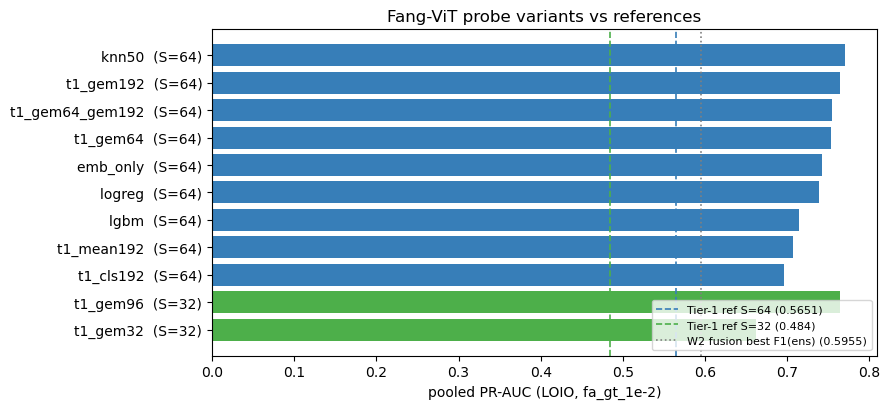

In [2]:
rows = []
for vj in sorted(PROBE.glob("*/*/verdict.json")):
    v = json.loads(vj.read_text(encoding="utf-8"))
    label = [k for k in v if k != "tier1_ref"][0]
    r = v[label]
    scale = 32 if ("gem32" in label or "gem96" in label or "_S32" in vj.parts[-3]) else 64
    rows.append({
        "variant": label, "S": scale,
        "pooled_pr": r["pooled_pr_auc"], "prec@5%": r["prec_at_5"],
        "med_auc": r["med_auc"], "dauc_med(v)": r["dauc_median_v"],
        "win": r["dauc_win_v"], "p": r["wilcoxon_p"],
        "gate_pooled": r["gate_pooled"], "gate_per_image": r["gate_per_image"],
        "t1_pooled_ref": v["tier1_ref"]["pooled_pr_auc"],
    })
vt = pd.DataFrame(rows).sort_values(["S", "pooled_pr"], ascending=[False, False]).reset_index(drop=True)
display(vt.round(4))

fig, ax = plt.subplots(figsize=(9, 4.2))
order = vt.sort_values(["S", "pooled_pr"])
colors = ["#377eb8" if s == 64 else "#4daf4a" for s in order["S"]]
ax.barh(order["variant"] + "  (S=" + order["S"].astype(str) + ")", order["pooled_pr"], color=colors)
for ref, s, c in ((0.5651, 64, "#377eb8"), (0.4840, 32, "#4daf4a")):
    ax.axvline(ref, color=c, ls="--", lw=1.2, label=f"Tier-1 ref S={s} ({ref})")
ax.axvline(0.5955, color="gray", ls=":", lw=1.2, label="W2 fusion best F1(ens) (0.5955)")
ax.set_xlabel("pooled PR-AUC (LOIO, fa_gt_1e-2)")
ax.set_title("Fang-ViT probe variants vs references")
ax.legend(fontsize=8, loc="lower right")
fig.tight_layout(); fig.savefig(FIG / "20_fang_verdicts.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Per-image ΔAUC structure — who gets rescued

ΔAUC = per-image AUC(t1_gem192) − AUC(Tier-1 S=64), colored by the W1
dossier `attributed_cause`. The historical failure classes
(`distribution_shift`, `texture_decorrelated`) are exactly where the FM
helps most; `validity_limited` (images whose AUC is barely measurable) is
the only negative class.

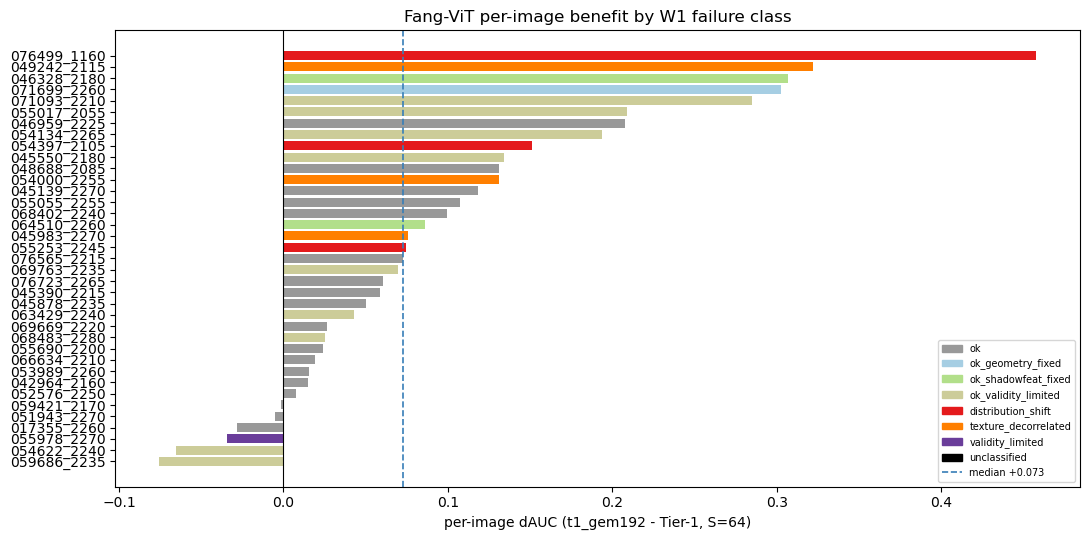

                        mean  count
attributed_cause                   
distribution_shift    0.2277      3
ok                    0.0543     18
ok_geometry_fixed     0.3024      1
ok_shadowfeat_fixed   0.1962      2
ok_validity_limited   0.0910      9
texture_decorrelated  0.1761      3
validity_limited     -0.0342      1


In [3]:
vj = sorted(PROBE.glob("t1_gem192/*/verdict.json"))[0]
v = json.loads(vj.read_text(encoding="utf-8"))
d = pd.Series(v["t1_gem192"]["per_image_dauc"], dtype=float).sort_values()
cause = DOSSIER["attributed_cause"].reindex(d.index).fillna("unclassified")
palette = {"ok": "#999999", "ok_geometry_fixed": "#a6cee3", "ok_shadowfeat_fixed": "#b2df8a",
           "ok_validity_limited": "#cccc99", "distribution_shift": "#e41a1c",
           "texture_decorrelated": "#ff7f00", "validity_limited": "#6a3d9a",
           "unclassified": "#000000"}
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.barh([o.replace("ESP_", "") for o in d.index], d.to_numpy(),
        color=[palette[c] for c in cause])
ax.axvline(0, color="k", lw=0.8)
ax.axvline(d.median(), color="#377eb8", ls="--", lw=1.2,
           label=f"median {d.median():+.3f}")
handles = [plt.Rectangle((0, 0), 1, 1, color=v_) for v_ in palette.values()]
ax.legend(handles + [ax.lines[-1]], list(palette) + [f"median {d.median():+.3f}"],
          fontsize=7, loc="lower right")
ax.set_xlabel("per-image dAUC (t1_gem192 - Tier-1, S=64)")
ax.set_title("Fang-ViT per-image benefit by W1 failure class")
fig.tight_layout(); fig.savefig(FIG / "20_fang_perimage_dauc.png", dpi=150, bbox_inches="tight")
plt.show()
print(d.groupby(cause).agg(["mean", "count"]).round(4))

## 3. Input-alignment visual check (Brian-requested)

The two ViT inputs per tile: the cached 64-px Stage-4b patch and a 192-px
3×3-context box sliced from the cached CTX window. The center 64×64 of every
192-px slice is asserted **bit-identical** to the cached patch during
extraction (sampled per image, all 38 images pass); these figures are the
eyeball version. Red/blue/green = max-label tile, nearest-to-window-edge
tile (slice-arithmetic stress case), median tile.

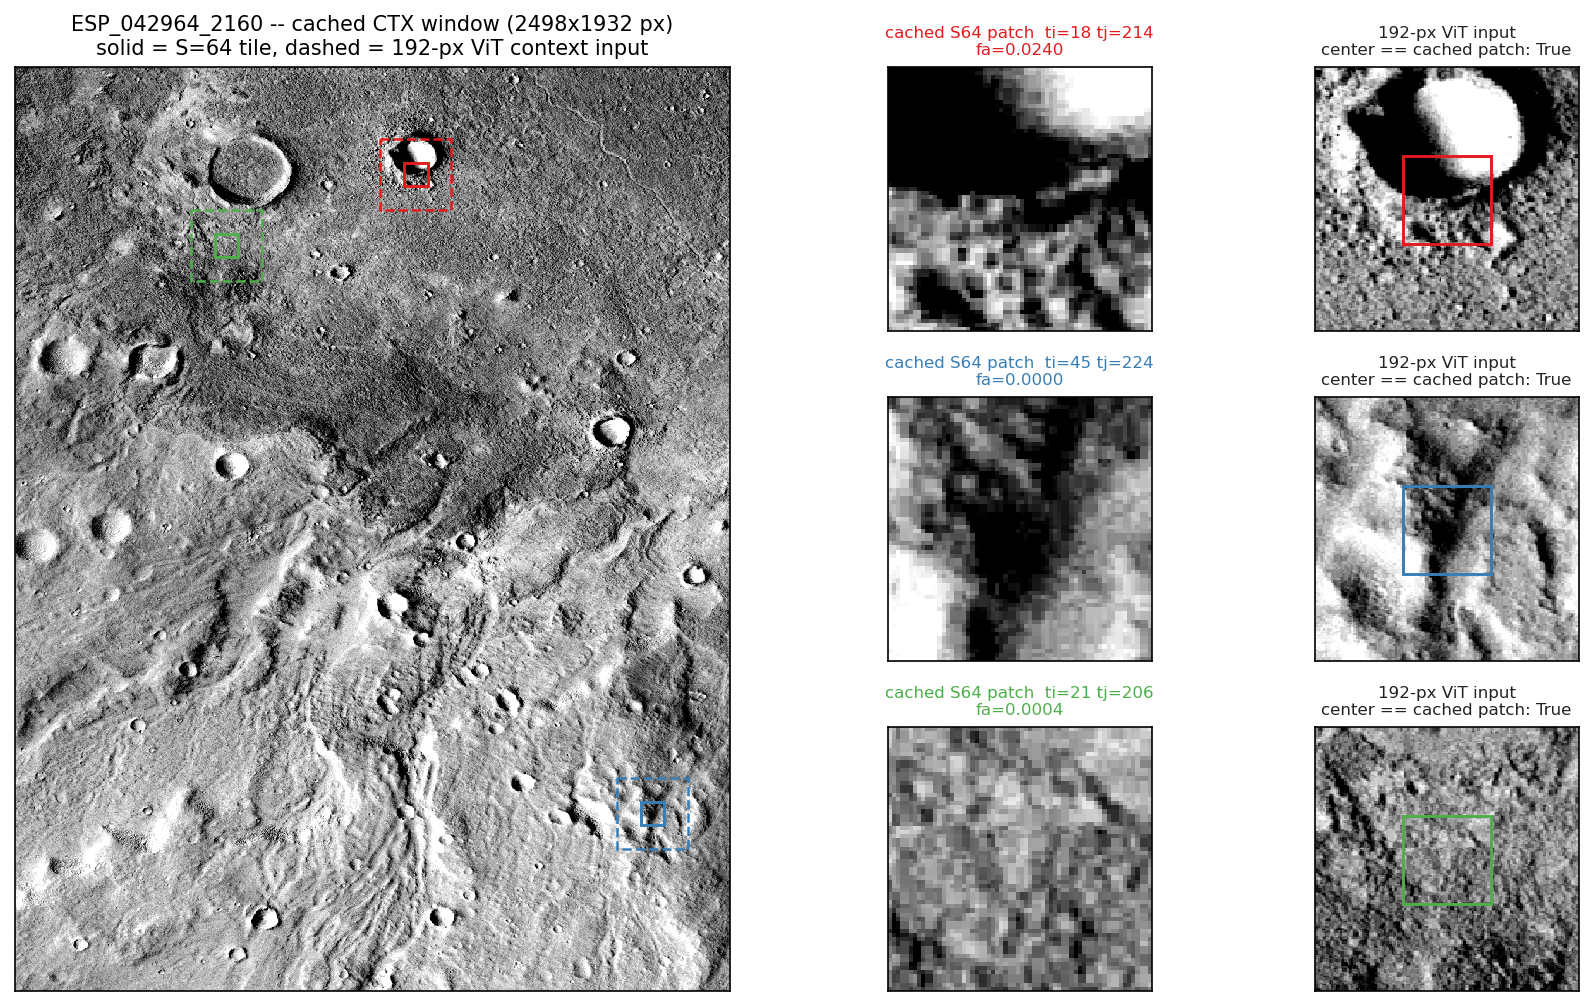

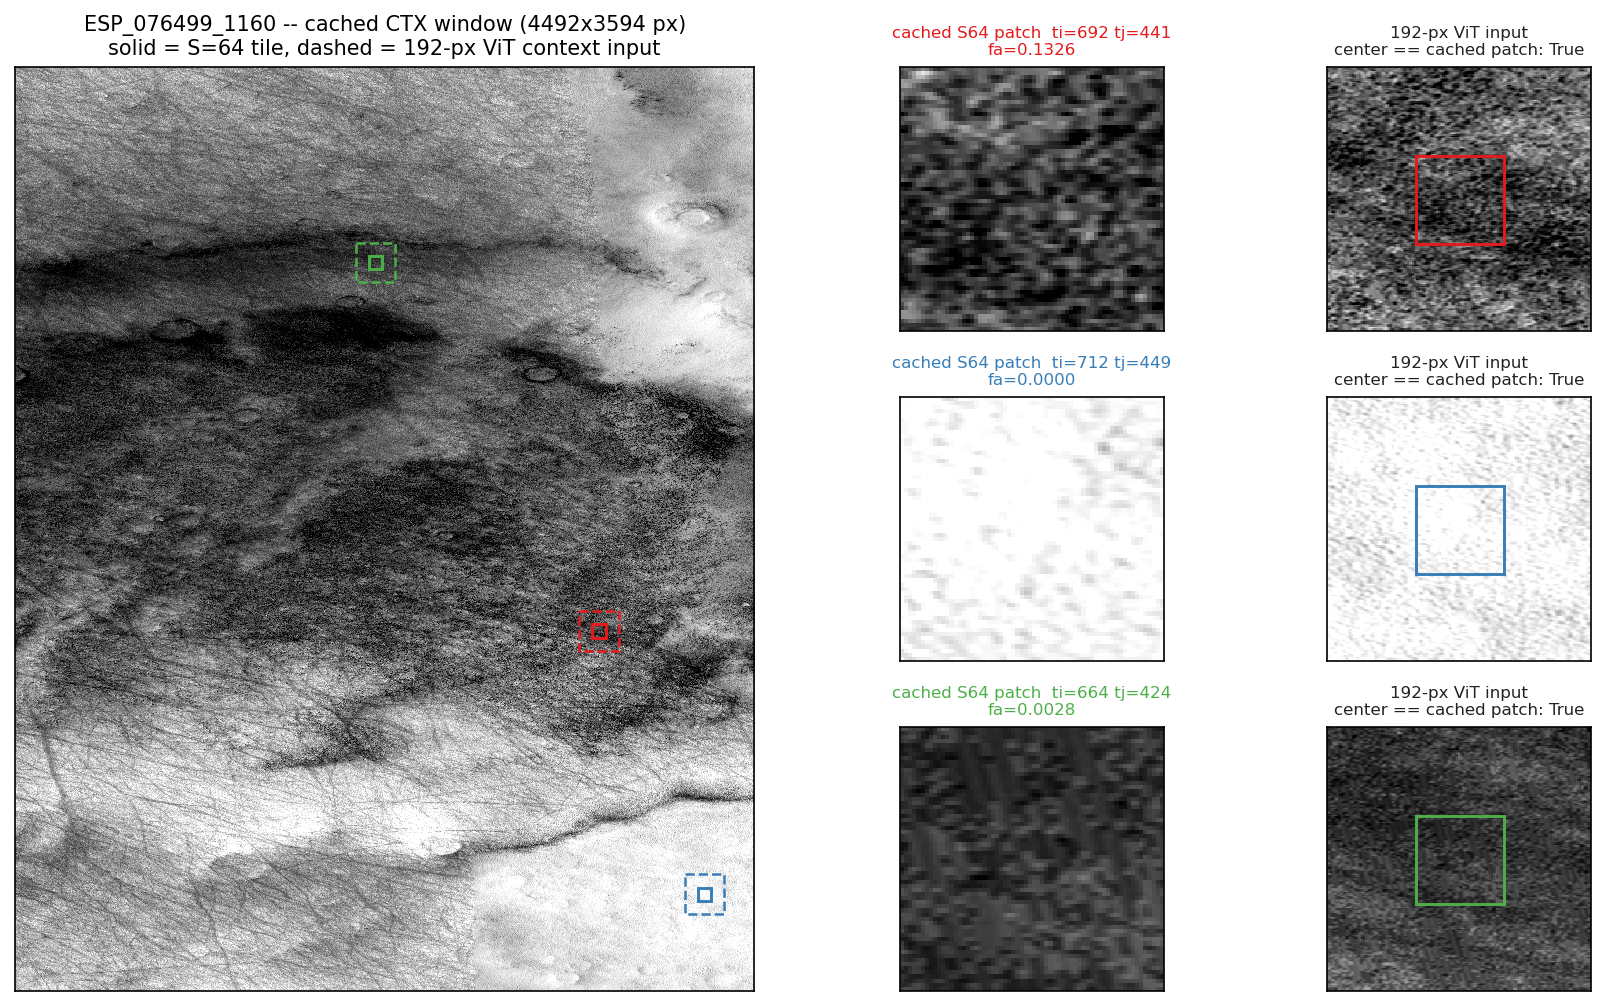

In [4]:
for obs in ("ESP_042964_2160", "ESP_076499_1160"):
    display(Image(filename=str(FIG / f"19_w2_fang_patch_alignment_{obs}.png"), width=900))

## 4. Azimuth-conditioned read — the paper's CBIR caveat

Fang et al. flag that high-incidence scenes produce shadow-dominated
embeddings that match by illumination. In our data the caveat is **present
but harmless**: sin(azimuth) is LOO-recoverable from image-mean embeddings
(r=+0.588, p=1e-4), yet the per-image benefit is geometry-agnostic
(ρ vs incidence −0.06 ns; vs azimuth-distance +0.16 ns) and the cohort's
**biggest winner is the azimuth outlier** ESP_076499_1160 (+0.458) — the
image that rotation augmentation, AdaBN, and z-scoring each only partially
rescued across W1–W2.

{
  "q1_dauc_vs_incidence": {
    "rho": -0.05809128630705395,
    "p": 0.7327151187242232
  },
  "q1_dauc_vs_az_dist": {
    "rho": 0.16016597510373445,
    "p": 0.3436666381221686
  },
  "q2_loo_ridge_geometry_from_embeddings": {
    "incidence": {
      "r": 0.2703785680708497,
      "p": 0.10555330579057773
    },
    "sin_az": {
      "r": 0.5884491101051899,
      "p": 0.00012781246818141268
    },
    "cos_az": {
      "r": 0.03855942181677387,
      "p": 0.8207490465477711
    }
  },
  "outliers": {
    "ESP_076499_1160": {
      "az": 228.5667266845703,
      "inc": 59.16709899902344,
      "dauc": 0.4576
    },
    "ESP_068483_2280": {
      "az": 1.7352999448776245,
      "inc": 4.275901794433594,
      "dauc": 0.0255
    }
  },
  "n_images": 37
}


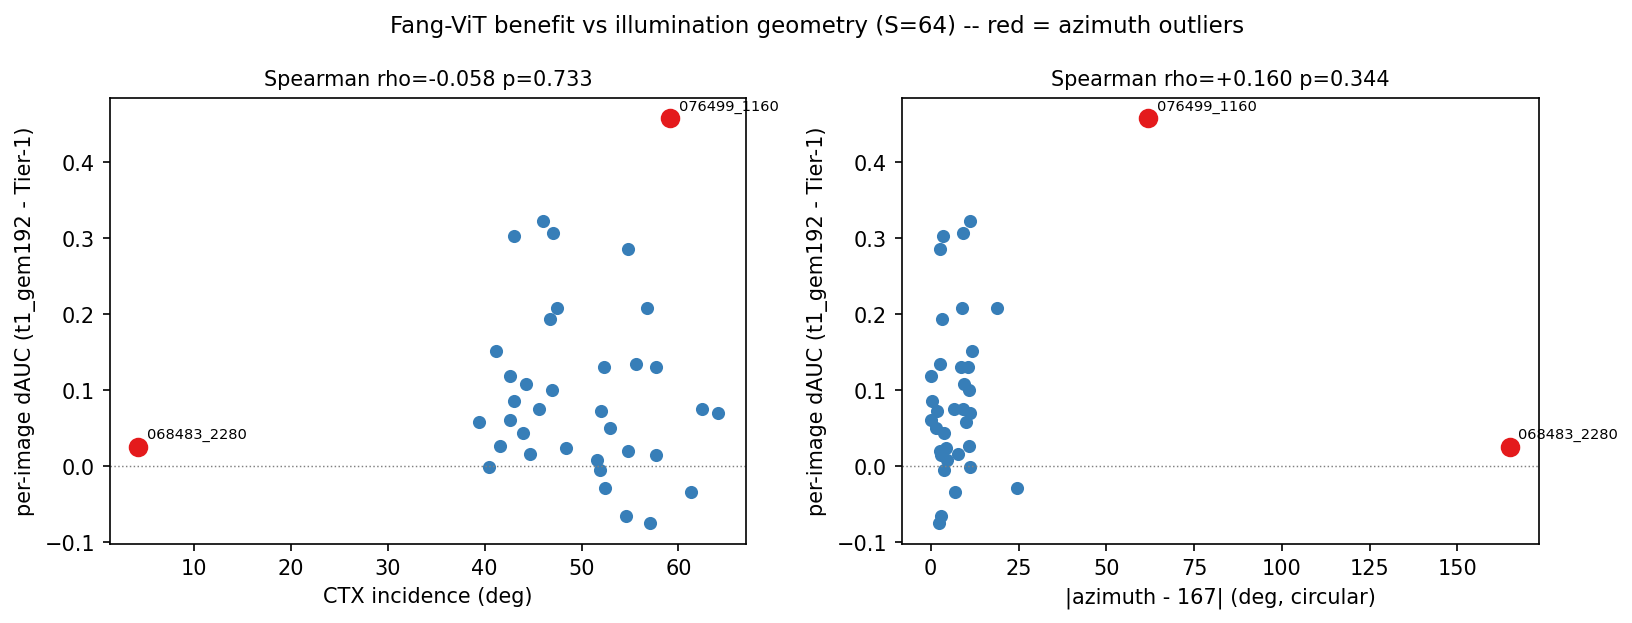

In [5]:
az = json.loads((vj.parent / "azimuth_read.json").read_text(encoding="utf-8"))
print(json.dumps(az, indent=2))
display(Image(filename=str(FIG / "19_w2_fang_azimuth_read.png"), width=900))

## 5. What the re-ranking looks like — top tiles on the azimuth outlier

Held-out top-8 tiles by score on ESP_076499_1160 (the +0.458 image):
t1_gem192 vs Tier-1, each tile shown as its 192-px context box with the
true label. The FM's top picks are nearly all true positives; Tier-1's
are mixed — the same contrast that prec@5% 0.977 vs 0.771 summarizes
cohort-wide.

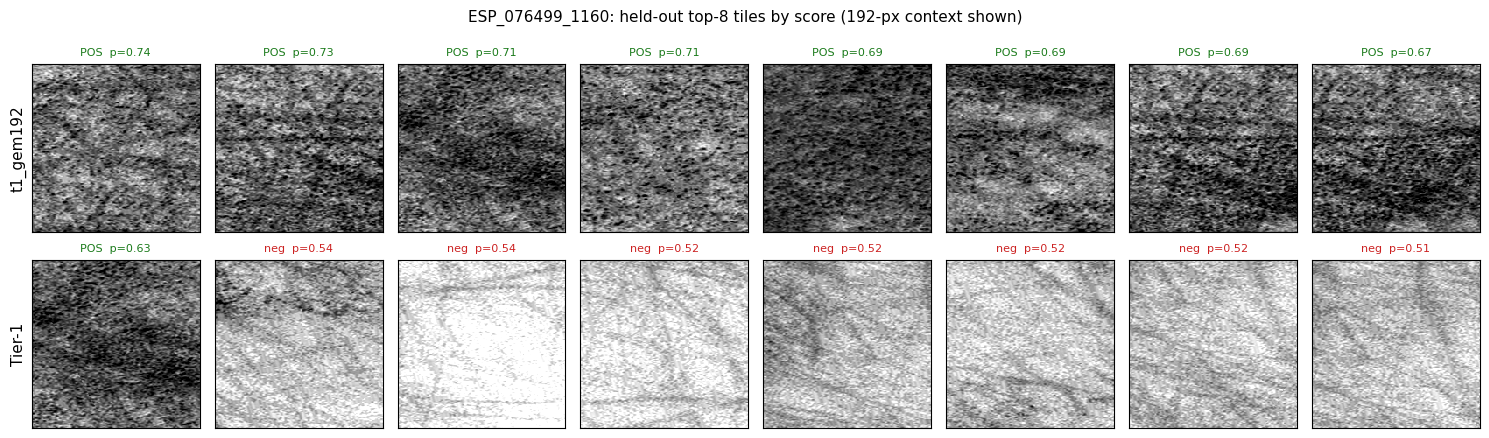

FM top-8 precision: 1.0   Tier-1 top-8 precision: 0.125


In [6]:
import rasterio

OBS = "ESP_076499_1160"
side = json.loads((REPO / f"dataset_v2/labels/{OBS}.json").read_text(encoding="utf-8"))
with rasterio.open(side["ctx_window_tif"]) as src:
    win = src.read(1).astype(np.uint8)
row0, col0 = int(side["mosaic_row_origin"]), int(side["mosaic_col_origin"])

fm = pd.read_parquet(sorted(PROBE.glob("t1_gem192/*/predictions.parquet"))[0])
fm = fm[fm.obs_id == OBS]
t1 = pd.read_parquet(REPO / "models/lightgbm_classification/99de85c1ad2a72e6/"
                            "scale_S64_tfa_gt_1e-2/predictions.parquet")
t1 = t1[t1.obs_id == OBS]

lo, hi = np.percentile(win[win > 0], [2, 98])
fig, axes = plt.subplots(2, 8, figsize=(15, 4.6))
for r, (df, name) in enumerate(((fm, "t1_gem192"), (t1, "Tier-1"))):
    top = df.nlargest(8, "y_pred")
    for c, (_, t) in enumerate(top.iterrows()):
        rw, cw = int(t.ti) * 64 - row0, int(t.tj) * 64 - col0
        patch = win[rw - 64: rw + 128, cw - 64: cw + 128]
        ax = axes[r, c]
        ax.imshow(patch, cmap="gray", vmin=lo, vmax=hi, interpolation="nearest")
        ok = bool(t.y_true)
        ax.set_title(("POS" if ok else "neg") + f"  p={t.y_pred:.2f}",
                     fontsize=8, color=("#1a7a1a" if ok else "#cc2222"))
        ax.set_xticks([]); ax.set_yticks([])
    axes[r, 0].set_ylabel(name, fontsize=11)
fig.suptitle(f"{OBS}: held-out top-8 tiles by score (192-px context shown)", fontsize=11)
fig.tight_layout()
fig.savefig(FIG / "20_fang_topk_ESP_076499_1160.png", dpi=150, bbox_inches="tight")
plt.show()
print("FM top-8 precision:", fm.nlargest(8, 'y_pred').y_true.mean(),
      "  Tier-1 top-8 precision:", t1.nlargest(8, 'y_pred').y_true.mean())

## 6. Truth vs model maps — slimmer-doc style

Same presentation (and the same two exemplar images) as Figure 5 of
[docs/classification_slimmer.md](../docs/classification_slimmer.md): per
image, LEFT = truth (tiles with `fractional_area ≥ 1e-2` highlighted),
RIGHT = the model's rich calls at **matched budget** (top-N tiles by
held-out `t1_gem192` score, N = the true rich count) — so the question is
purely *whether it picks the same tiles*. Under the 5-feature slim model
these two images scored AUC 0.880 (good) and **0.344 (anti-signal — worse
than chance)**; the FM recipe's numbers are in the panel titles.

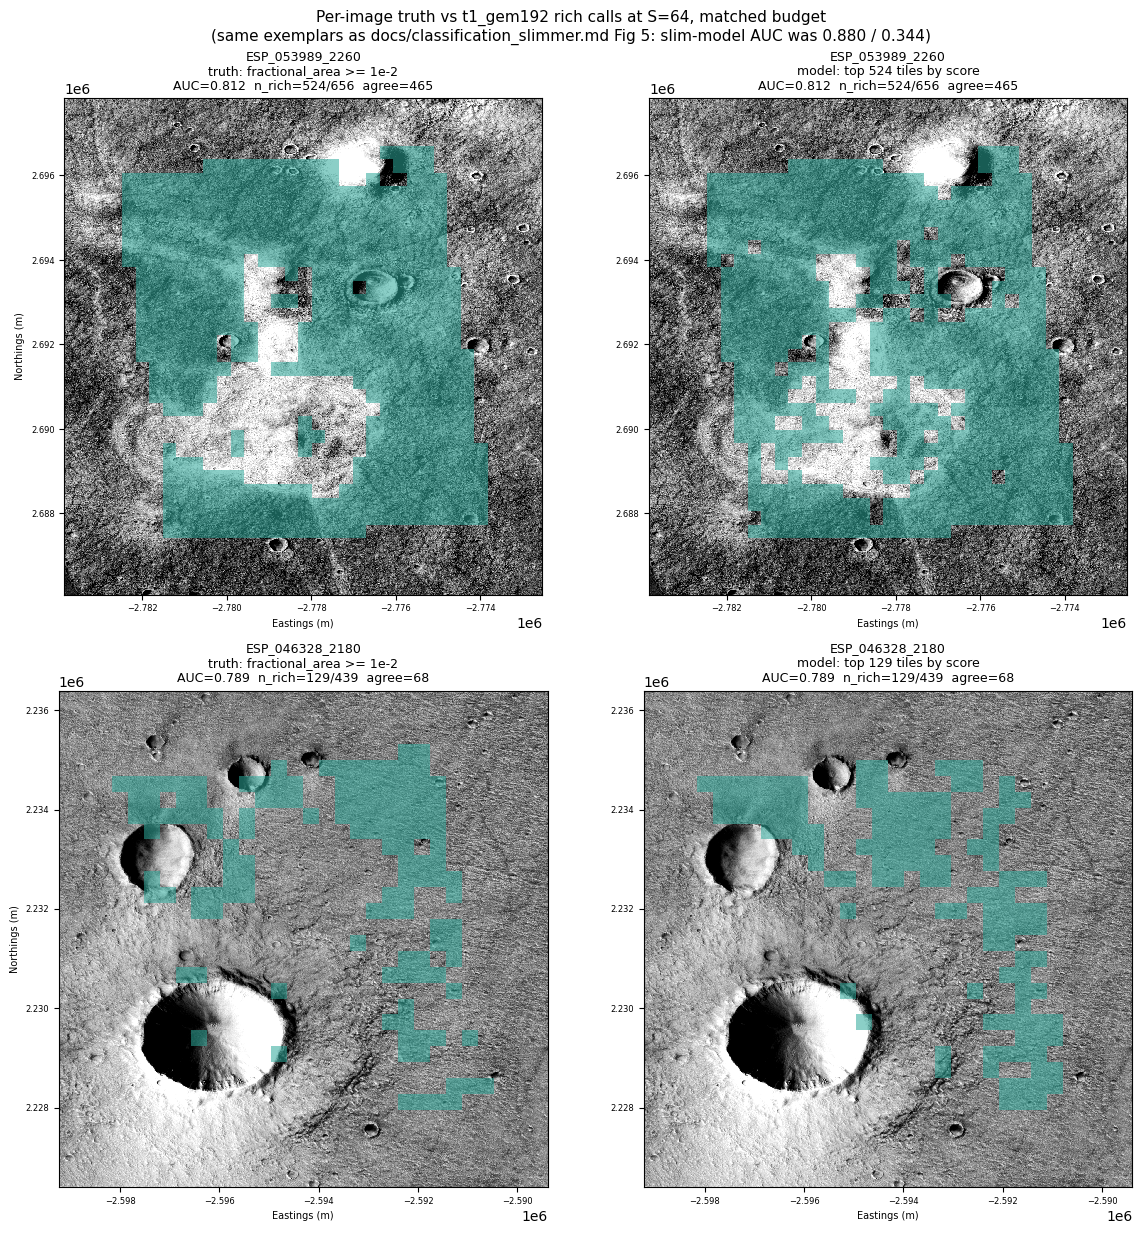

In [7]:
import rasterio
from sklearn.metrics import roc_auc_score

EXEMPLARS = ["ESP_053989_2260", "ESP_046328_2180"]  # slimmer-doc Fig 5 pair
fm_all = pd.read_parquet(sorted(PROBE.glob("t1_gem192/*/predictions.parquet"))[0])

fig, axes = plt.subplots(2, 2, figsize=(12, 12.5))
for r, obs in enumerate(EXEMPLARS):
    side = json.loads((REPO / f"dataset_v2/labels/{obs}.json").read_text(encoding="utf-8"))
    with rasterio.open(side["ctx_window_tif"]) as src:
        win = src.read(1).astype(np.uint8)
        b = src.bounds
    extent = (b.left, b.right, b.bottom, b.top)
    row0, col0 = int(side["mosaic_row_origin"]), int(side["mosaic_col_origin"])

    df = fm_all[fm_all.obs_id == obs]
    n_rich = int(df.y_true.sum())
    auc = roc_auc_score(df.y_true, df.y_pred)
    called = set(df.nlargest(n_rich, "y_pred")[["ti", "tj"]].itertuples(index=False, name=None))
    truth = set(df[df.y_true == 1][["ti", "tj"]].itertuples(index=False, name=None))
    agree = len(called & truth)

    lo, hi = np.percentile(win[win > 0], [2, 98])
    for c, (tiles, kind) in enumerate(((truth, "truth: fractional_area >= 1e-2"),
                                       (called, f"model: top {n_rich} tiles by score"))):
        mask = np.zeros(win.shape, dtype=np.uint8)
        for ti, tj in tiles:
            rw, cw = int(ti) * 64 - row0, int(tj) * 64 - col0
            mask[rw: rw + 64, cw: cw + 64] = 1
        ax = axes[r, c]
        ax.imshow(win, cmap="gray", vmin=lo, vmax=hi, extent=extent, interpolation="nearest")
        overlay = np.ma.masked_where(mask == 0, mask)
        ax.imshow(overlay, cmap=plt.matplotlib.colors.ListedColormap(["#2ca89a"]),
                  alpha=0.55, extent=extent, interpolation="nearest")
        ax.set_title(f"{obs}\n{kind}\nAUC={auc:.3f}  n_rich={n_rich}/{len(df)}  agree={agree}",
                     fontsize=9)
        ax.tick_params(labelsize=6)
        ax.set_xlabel("Eastings (m)", fontsize=7)
        if c == 0:
            ax.set_ylabel("Northings (m)", fontsize=7)
fig.suptitle("Per-image truth vs t1_gem192 rich calls at S=64, matched budget\n"
             "(same exemplars as docs/classification_slimmer.md Fig 5: slim-model "
             "AUC was 0.880 / 0.344)", fontsize=11)
fig.tight_layout()
fig.savefig(FIG / "20_fang_truth_vs_model.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Disposition

> **SUPERSEDED 2026-06-12 (read as a dated probe-phase record).** This
> notebook documents the probe phase; its conclusion below (LightGBM on
> `t1_gem192`) was overtaken the same day by two later results in
> [DECISIONS.md](../DECISIONS.md): (1) the **head bake-off** -- trees are the
> wrong reader of dense embeddings; the **3-seed MLP ensemble** is decisive
> (pooled 0.5651->0.8040 / med per-image AUC 0.8284 / win 0.96 on `t1+gem192`);
> and (2) the **freeze window**, which froze ONE recipe with Brian sign-off:
> **`mlp_ens3` on the S=32 96-px 3x3-context GeM(p=3) embedding, emb-only (no
> handcrafted features), target `fa_gt_1e-2`** (pooled 0.7832 / prec@5% 0.948 /
> med AUC 0.7865, both gates pass) -- chosen for a 4x finer map at held skill
> where feature elimination is free. The probe verdicts in sections 1-6 stand
> as reported; only the forward-looking pick below changed.

The probe phase is **closed**. The candidate Tier-1 replacement at both
scales is *Tier-1 features + GeM context-input Fang-ViT embeddings →
LightGBM* (t1_gem192 if pooled PR-AUC is binding; t1_gem64_gem192 if
per-image skill is). Next per
[HANDOFF_NEXT_SESSION.md](../HANDOFF_NEXT_SESSION.md): productize the
extraction into `src/` (embed arbitrary CTX windows + tests), pre-declare
confirmation gates on the cohort-expansion images **before** seeing any
new-image numbers, then rebuild the Tier-2 calibrated head on the new
feature set. The conditional-leveler fusion recipe is likely obsolete and
is retired formally after the confirmation read. Fine-tuning the ViT stays
deferred.